# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [3]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [4]:
# Load the csv file from the provided path
file_1 = '/content/Churn_Modelling.csv'

In [5]:
# make into a dataframe called df
df = pd.read_csv(file_1)

In [6]:
# output the first 5 lines
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# Create two separate DataFrames, df_0 and df_1
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

print(f"Customers who stayed: {len(df_0)}")
print(f"Customers who left: {len(df_1)}")

Customers who stayed: 7963
Customers who left: 2037


## Hypothesis 1: Age

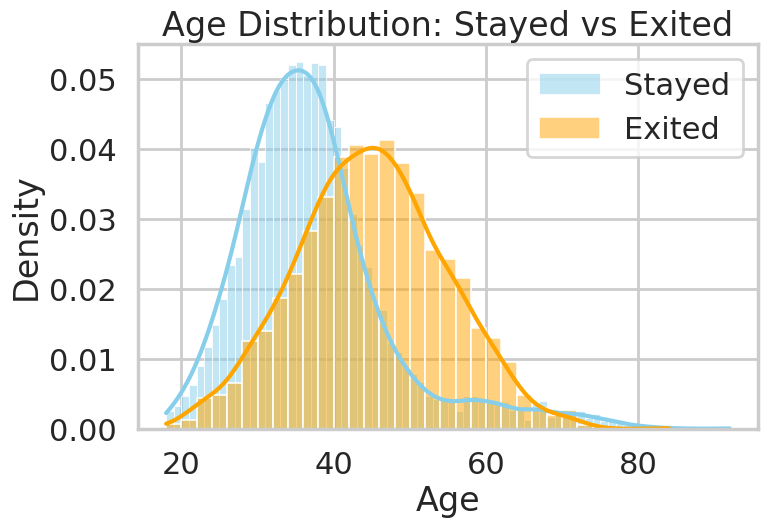

In [8]:
# Plot the age distribution for customers who stayed and those who left
sns.histplot(df_0['Age'], color='skyblue', label='Stayed', kde=True, stat='density')
sns.histplot(df_1['Age'], color='orange', label='Exited', kde=True, stat='density')
plt.title('Age Distribution: Stayed vs Exited')
plt.xlabel('Age')
plt.legend()
plt.show()

In [9]:
# Calculate mean and std for customers who stayed
mean_age_stayed = df_0['Age'].mean()
std_age_stayed = df_0['Age'].std()
print(f"Stayed - Mean Age: {mean_age_stayed:.2f}, Std Dev: {std_age_stayed:.2f}")

Stayed - Mean Age: 37.41, Std Dev: 10.13


In [10]:
# Calculate mean and std for customers who left
mean_age_exited = df_1['Age'].mean()
std_age_exited = df_1['Age'].std()
print(f"Exited - Mean Age: {mean_age_exited:.2f}, Std Dev: {std_age_exited:.2f}")

Exited - Mean Age: 44.84, Std Dev: 9.76


In [11]:
# Perform t-test for Age
t_stat, p_val = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

T-statistic: -30.4192
P-value: 4.7127e-179


### Using Bootstrapping

In [12]:
## Function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [13]:
# Calculate the difference in means and shift the ages to the overall mean
mean_diff = np.mean(df_1['Age']) - np.mean(df_0['Age'])
age_mean = np.mean(df['Age'])

# Shift the distributions
df_0_shifted = df_0['Age'] - np.mean(df_0['Age']) + age_mean
df_1_shifted = df_1['Age'] - np.mean(df_1['Age']) + age_mean

print(f"Observed difference in means: {mean_diff:.2f}")

Observed difference in means: 7.43


In [14]:
# Perform bootstrap sampling
seed(42)
bs_0 = bs_choice(df_0_shifted, np.mean, 10000)
bs_1 = bs_choice(df_1_shifted, np.mean, 10000)

bs_diff = bs_1 - bs_0

In [15]:
# Calculate the p-value
p_val_bs = np.sum(bs_diff >= mean_diff) / len(bs_diff)
print(f"Bootstrap p-value: {p_val_bs}")

Bootstrap p-value: 0.0


### Conclusion
**Reject the Null Hypothesis.** The p-value (4.71e-179) is significantly lower than 0.05. The visualization and statistics show that customers who left are, on average, older (mean ~45) than those who stayed (mean ~37).

## Hypothesis 2: Credit Score

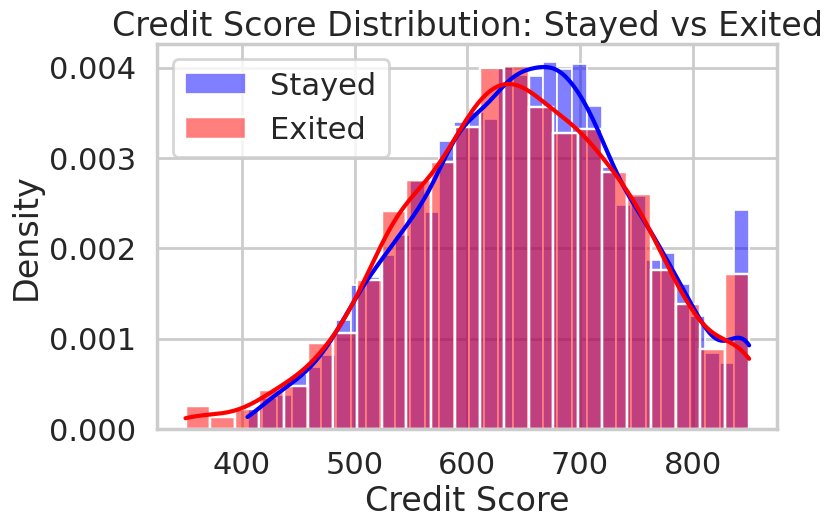

In [16]:
# Create histograms for the CreditScore distribution
sns.histplot(df_0['CreditScore'], color='blue', label='Stayed', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['CreditScore'], color='red', label='Exited', kde=True, stat='density', alpha=0.5)
plt.title('Credit Score Distribution: Stayed vs Exited')
plt.xlabel('Credit Score')
plt.legend()
plt.show()

In [17]:
# Perform a t-test to compare CreditScore
t_stat_cs, p_val_cs = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"T-statistic for Credit Score: {t_stat_cs:.4f}")
print(f"P-value for Credit Score: {p_val_cs:.4f}")

T-statistic for Credit Score: 2.6347
P-value for Credit Score: 0.0085


### Conclusion
**Reject the Null Hypothesis.** The p-value (0.0085) is below 0.05. Although the distributions look similar, there is a statistically significant difference in credit scores between the two groups.

## Hypothesis 3: Balance

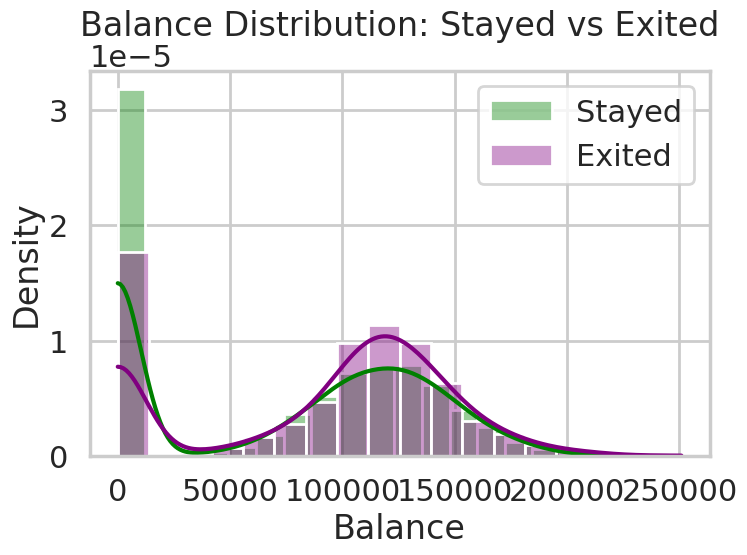

In [18]:
# Plot the distribution of Balance for both groups
sns.histplot(df_0['Balance'], color='green', label='Stayed', kde=True, stat='density', alpha=0.4)
sns.histplot(df_1['Balance'], color='purple', label='Exited', kde=True, stat='density', alpha=0.4)
plt.title('Balance Distribution: Stayed vs Exited')
plt.legend()
plt.show()

In [19]:
# Perform a t-test to compare the Balance
t_stat_bal, p_val_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"T-statistic for Balance: {t_stat_bal:.4f}")
print(f"P-value for Balance: {p_val_bal:.4e}")

T-statistic for Balance: -12.4713
P-value for Balance: 6.3187e-35


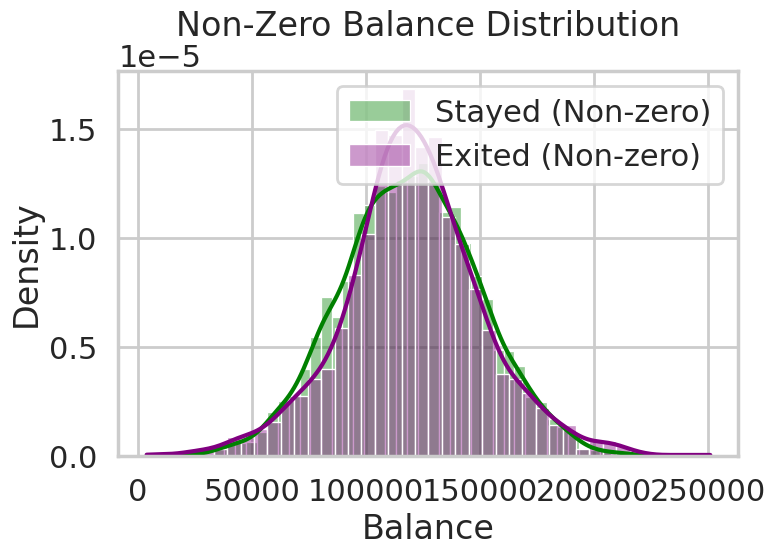

In [20]:
# Visualize Balance excluding zero balances
df_0_nonzero = df_0[df_0['Balance'] > 0]
df_1_nonzero = df_1[df_1['Balance'] > 0]

sns.histplot(df_0_nonzero['Balance'], color='green', label='Stayed (Non-zero)', kde=True, stat='density', alpha=0.4)
sns.histplot(df_1_nonzero['Balance'], color='purple', label='Exited (Non-zero)', kde=True, stat='density', alpha=0.4)
plt.title('Non-Zero Balance Distribution')
plt.legend()
plt.show()

In [21]:
# T-test for non-zero balances
t_stat_nz, p_val_nz = scipy.stats.ttest_ind(df_0_nonzero['Balance'], df_1_nonzero['Balance'], equal_var=False)
print(f"Non-zero Balance T-stat: {t_stat_nz:.4f}, P-value: {p_val_nz:.4f}")

Non-zero Balance T-stat: -1.3605, P-value: 0.1738


### Conclusion
**Reject the Null Hypothesis for total balance, but Fail to Reject for non-zero balances.** While the overall balance is significantly different (p-value 6.31e-35) due to the large number of zero-balance accounts in the 'stayed' group, the difference disappears when looking only at customers with active balances (p-value 0.1738).

## Hypothesis 4: Estimated Salary

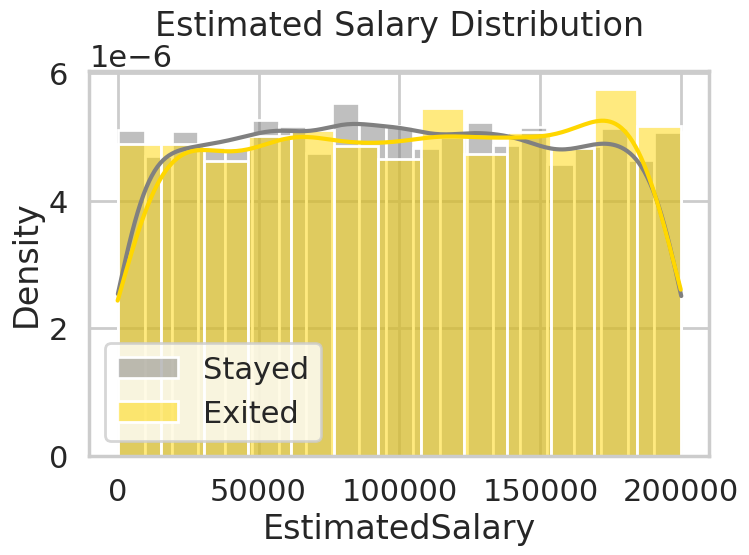

In [22]:
# Plot the distribution of EstimatedSalary
sns.histplot(df_0['EstimatedSalary'], color='grey', label='Stayed', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['EstimatedSalary'], color='gold', label='Exited', kde=True, stat='density', alpha=0.5)
plt.title('Estimated Salary Distribution')
plt.legend()
plt.show()

In [23]:
# Perform a t-test for EstimatedSalary
t_stat_sal, p_val_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"Estimated Salary T-stat: {t_stat_sal:.4f}, P-value: {p_val_sal:.4f}")

Estimated Salary T-stat: -1.2034, P-value: 0.2289


### Using Bootstrapping

In [24]:
# Bootstrapping for Estimated Salary
obs_diff_sal = np.mean(df_1['EstimatedSalary']) - np.mean(df_0['EstimatedSalary'])
sal_mean_global = df['EstimatedSalary'].mean()

df_0_sal_shifted = df_0['EstimatedSalary'] - df_0['EstimatedSalary'].mean() + sal_mean_global
df_1_sal_shifted = df_1['EstimatedSalary'] - df_1['EstimatedSalary'].mean() + sal_mean_global

In [25]:
# Bootstrap sample means for salary
seed(42)
bs_0_sal = bs_choice(df_0_sal_shifted, np.mean, 10000)
bs_1_sal = bs_choice(df_1_sal_shifted, np.mean, 10000)
bs_diff_sal = bs_1_sal - bs_0_sal

In [26]:
# P-value for bootstrap salary test
p_val_bs_sal = np.sum(bs_diff_sal >= obs_diff_sal) / len(bs_diff_sal)
print(f"Bootstrap Salary P-value: {p_val_bs_sal}")

Bootstrap Salary P-value: 0.1149


### Conclusion
**Fail to Reject the Null Hypothesis.** Both the t-test (p=0.2289) and the bootstrap test (p=0.1149) result in p-values greater than 0.05, suggesting that Estimated Salary is not a primary differentiator for churning.

## Final Conclusion
Based on the analysis, **Age** is the most helpful feature among the four tested for predicting churning, as it showed the most dramatic difference in distribution and the lowest p-value. **Balance** (presence of a balance) and **Credit Score** are also significant, while **Estimated Salary** appears to have little to no impact on a customer's decision to leave.